# Comparison between classical subset, hybrid subset, classical full, and hybrid full

This notebook compares all four runs in one place: classical subset, hybrid subset, classical full, and hybrid full.

It loads the saved metrics and configs, compares the final performance numbers, and can also evaluate the saved model weights for confusion matrices when the model files are present.

In [1]:
import os
import sys
import yaml
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.classical_cnn import ClassicalCNN
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Each entry below points to one of the four experiment configs and the results directory that should contain its saved metrics and model checkpoint.

In [2]:
RUNS = [
    {'label': 'classical_subset', 'config': project_root / 'configs' / 'classical_subset.yaml', 'results_dir': project_root / 'results' / 'classical_subset', 'kind': 'classical'},
    {'label': 'hybrid_subset', 'config': project_root / 'configs' / 'hybrid.yaml', 'results_dir': project_root / 'results' / 'hybrid', 'kind': 'hybrid'},
    {'label': 'classical_full', 'config': project_root / 'configs' / 'classical_full.yaml', 'results_dir': project_root / 'results' / 'classical_full', 'kind': 'classical'},
    {'label': 'hybrid_full', 'config': project_root / 'configs' / 'hybrid_full.yaml', 'results_dir': project_root / 'results' / 'hybrid_full', 'kind': 'hybrid'},
]

def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

def build_model(spec, config):
    model_cfg = config['model']
    if spec['kind'] == 'classical':
        model = ClassicalCNN(num_classes=model_cfg['num_classes'])
    else:
        model = HybridCNN(
            num_classes=model_cfg['num_classes'],
            n_qubits=model_cfg.get('n_qubits', 4),
            n_qlayers=model_cfg.get('n_qlayers', 2),
            device=model_cfg.get('device', 'default.qubit'),
        )
    state_path = spec['results_dir'] / 'model.pt'
    if state_path.exists():
        model.load_state_dict(torch.load(state_path, map_location='cpu'))
        print(f"{spec['label']}: loaded {state_path.name}")
    else:
        print(f"{spec['label']}: no saved weights found at {state_path}")
    return model

print('Configured runs:')
for spec in RUNS:
    print(spec['label'], '->', spec['config'])

Configured runs:
classical_subset -> D:\Dissertation\qcnn-dissertation\configs\classical_subset.yaml
hybrid_subset -> D:\Dissertation\qcnn-dissertation\configs\hybrid.yaml
classical_full -> D:\Dissertation\qcnn-dissertation\configs\classical_full.yaml
hybrid_full -> D:\Dissertation\qcnn-dissertation\configs\hybrid_full.yaml


## 1. Dataset and run summary

This section summarises the dataset choice, sample size, and training configuration for every run.

In [3]:
summary_rows = []
for spec in RUNS:
    config = load_config(spec['config'])
    ds = config['dataset']
    training = config['training']
    model_cfg = config['model']
    if ds.get('full', False):
        row = {
            'run': spec['label'],
            'mode': 'full_mnist',
            'classes': ds['classes'],
            'train_samples': 60000,
            'test_samples': 10000,
            'seed': config.get('seed'),
            'epochs': training.get('epochs'),
            'batch_size': training.get('batch_size'),
            'learning_rate': training.get('learning_rate'),
            'n_qubits': model_cfg.get('n_qubits'),
            'n_qlayers': model_cfg.get('n_qlayers'),
        }
    else:
        row = {
            'run': spec['label'],
            'mode': 'subset',
            'classes': ds['classes'],
            'train_samples': len(ds['classes']) * ds.get('samples_per_class_train', 0),
            'test_samples': len(ds['classes']) * ds.get('samples_per_class_test', 0),
            'seed': config.get('seed'),
            'epochs': training.get('epochs'),
            'batch_size': training.get('batch_size'),
            'learning_rate': training.get('learning_rate'),
            'n_qubits': model_cfg.get('n_qubits'),
            'n_qlayers': model_cfg.get('n_qlayers'),
        }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,run,mode,classes,train_samples,test_samples,seed,epochs,batch_size,learning_rate,n_qubits,n_qlayers
0,classical_subset,subset,"[0, 1, 2]",900,300,42,15,32,0.001,NaN,NaN
1,hybrid_subset,subset,"[0, 1, 2]",900,300,42,15,32,0.001,4.0,2.0
2,classical_full,full_mnist,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",60000,10000,42,12,64,0.001,NaN,NaN
3,hybrid_full,full_mnist,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",60000,10000,42,12,64,0.001,8.0,2.0


## 2. Load metrics from each run

This cell reads the saved metrics.csv files and shows the per-epoch records for each run.

In [4]:
metrics_by_run = {}
for spec in RUNS:
    csv_path = spec['results_dir'] / 'metrics.csv'
    if csv_path.exists():
        metrics_by_run[spec['label']] = pd.read_csv(csv_path)
        print(f"{spec['label']}: loaded {len(metrics_by_run[spec['label']])} epochs")
    else:
        print(f"{spec['label']}: no metrics.csv found")

for label, df in metrics_by_run.items():
    print(f"\n{label}:")
    display(df.tail())


classical_subset: loaded 15 epochs
hybrid_subset: loaded 15 epochs
classical_full: loaded 12 epochs
hybrid_full: loaded 12 epochs

classical_subset:


,epoch,train_loss,test_loss,epoch_time_sec,seed,accuracy,f1_macro,precision_macro,recall_macro,parameter_count
10,11,0.010909,0.029183,0.325193,42,0.990000,0.990017,0.990066,0.990000,51683
11,12,0.007007,0.040582,0.309409,42,0.990000,0.990017,0.990066,0.990000,51683
12,13,0.004169,0.036764,0.312851,42,0.993333,0.993333,0.993366,0.993333,51683
13,14,0.004478,0.035470,0.308056,42,0.990000,0.990017,0.990066,0.990000,51683
14,15,0.006129,0.056501,0.313696,42,0.980000,0.980061,0.980538,0.980000,51683



hybrid_subset:


,epoch,train_loss,test_loss,epoch_time_sec,seed,accuracy,f1_macro,precision_macro,recall_macro,parameter_count
10,11,0.604024,0.596643,0.729623,42,0.956667,0.956735,0.960260,0.956667,2299
11,12,0.573823,0.564255,0.752196,42,0.973333,0.973432,0.973660,0.973333,2299
12,13,0.539973,0.530903,0.746043,42,0.976667,0.976716,0.976799,0.976667,2299
13,14,0.513773,0.500817,0.756867,42,0.973333,0.973409,0.973896,0.973333,2299
14,15,0.482634,0.474365,0.730864,42,0.976667,0.976814,0.978193,0.976667,2299



classical_full:


,epoch,train_loss,test_loss,epoch_time_sec,seed,accuracy,f1_macro,precision_macro,recall_macro,parameter_count
7,8,0.020079,0.031245,18.541233,42,0.9889,0.988856,0.988861,0.988900,52138
8,9,0.016149,0.034304,18.837244,42,0.9900,0.989917,0.989904,0.989934,52138
9,10,0.014076,0.046865,19.931085,42,0.9865,0.986441,0.986624,0.986417,52138
10,11,0.012824,0.040261,19.753079,42,0.9885,0.988462,0.988578,0.988413,52138
11,12,0.010440,0.051560,21.765038,42,0.9867,0.986674,0.986735,0.986772,52138



hybrid_full:


,epoch,train_loss,test_loss,epoch_time_sec,seed,accuracy,f1_macro,precision_macro,recall_macro,parameter_count
7,8,0.181060,0.164424,286.144636,42,0.9628,0.962818,0.963337,0.962776,3410
8,9,0.158535,0.138195,332.018683,42,0.9654,0.965234,0.965336,0.965286,3410
9,10,0.142296,0.130403,337.659618,42,0.9678,0.967567,0.967755,0.967563,3410
10,11,0.128014,0.122950,313.727126,42,0.9683,0.968065,0.968290,0.967931,3410
11,12,0.119114,0.111797,304.151814,42,0.9707,0.970524,0.970620,0.970616,3410


In [5]:
metric_cols = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'test_loss', 'epoch_time_sec']
comparison_rows = []
for spec in RUNS:
    df = metrics_by_run.get(spec['label'])
    if df is None or df.empty:
        continue
    last_row = df.iloc[-1]
    row = {'run': spec['label']} | {col: last_row.get(col) for col in metric_cols}
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,run,accuracy,f1_macro,precision_macro,recall_macro,test_loss,epoch_time_sec
0,classical_subset,0.980000,0.980061,0.980538,0.980000,0.056501,0.313696
1,hybrid_subset,0.976667,0.976814,0.978193,0.976667,0.474365,0.730864
2,classical_full,0.986700,0.986674,0.986735,0.986772,0.051560,21.765038
3,hybrid_full,0.970700,0.970524,0.970620,0.970616,0.111797,304.151814


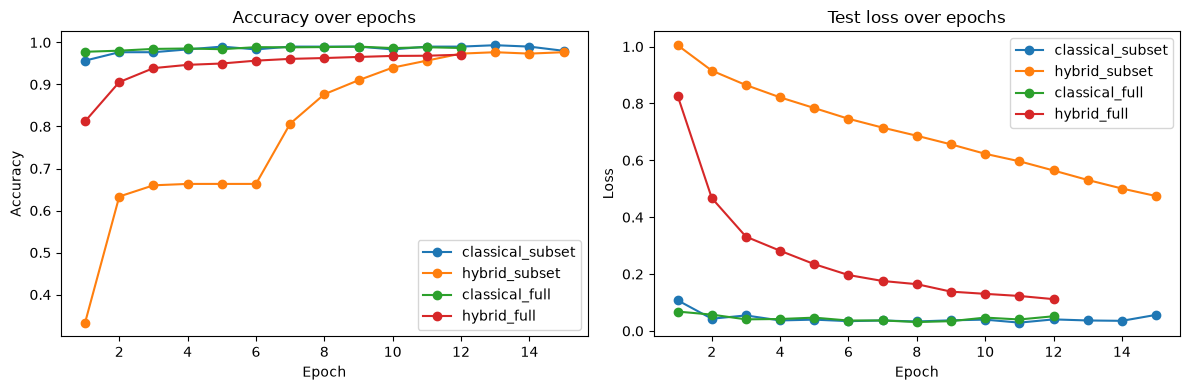

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, df in metrics_by_run.items():
    if 'accuracy' in df.columns:
        axes[0].plot(df['epoch'], df['accuracy'], marker='o', label=label)
    if 'test_loss' in df.columns:
        axes[1].plot(df['epoch'], df['test_loss'], marker='o', label=label)

axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Test loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


classical_subset: loaded model.pt
Saved D:\Dissertation\qcnn-dissertation\results\classical_subset\confusion_matrix.png


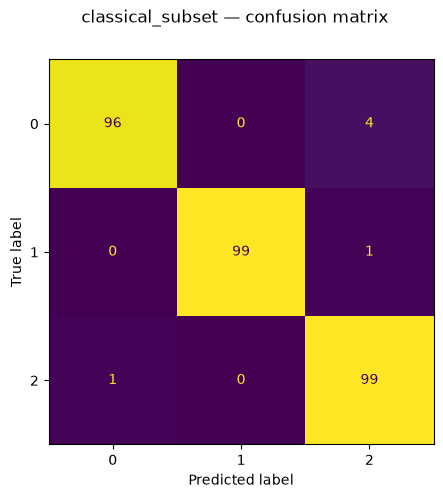

hybrid_subset: loaded model.pt
Saved D:\Dissertation\qcnn-dissertation\results\hybrid\confusion_matrix.png


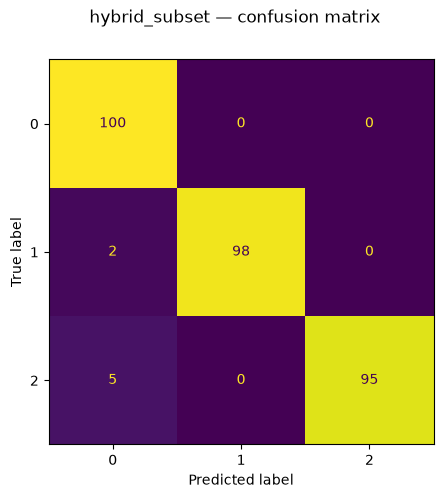

classical_full: loaded model.pt


Saved D:\Dissertation\qcnn-dissertation\results\classical_full\confusion_matrix.png


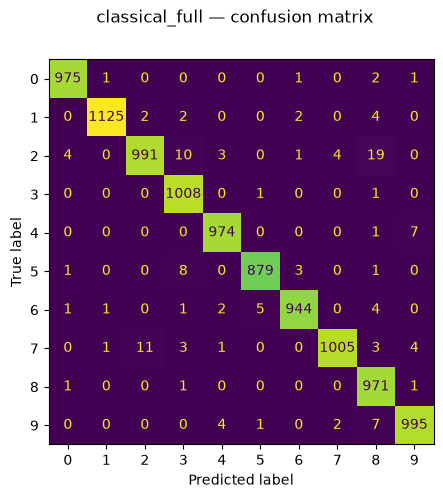

hybrid_full: loaded model.pt


Saved D:\Dissertation\qcnn-dissertation\results\hybrid_full\confusion_matrix.png


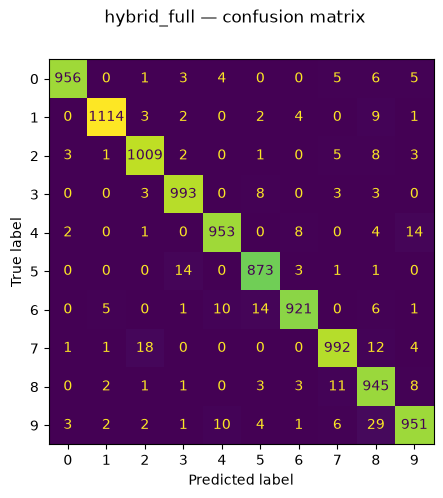

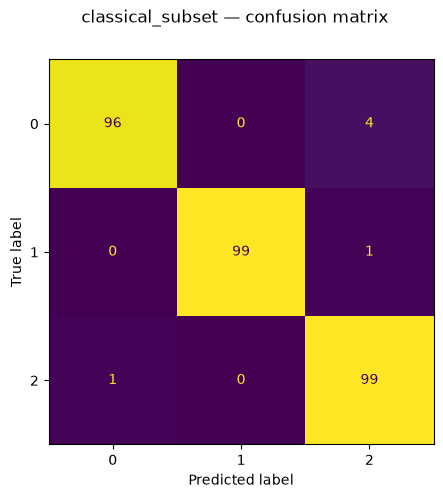

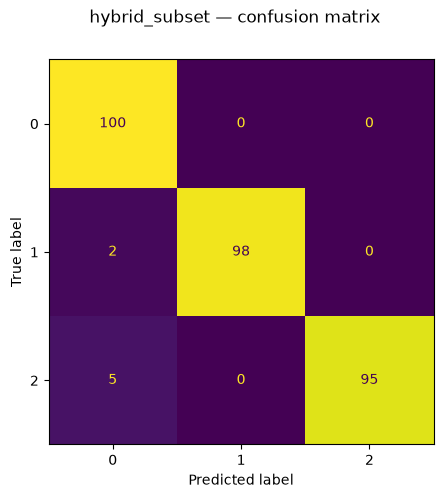

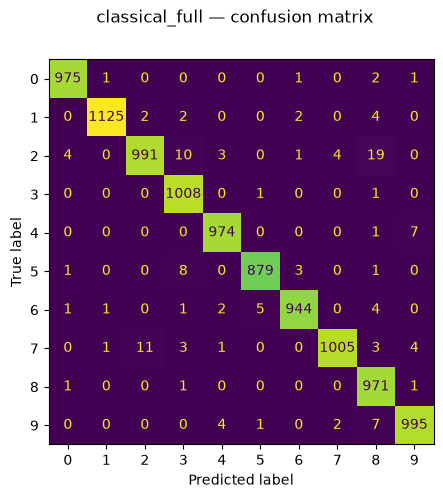

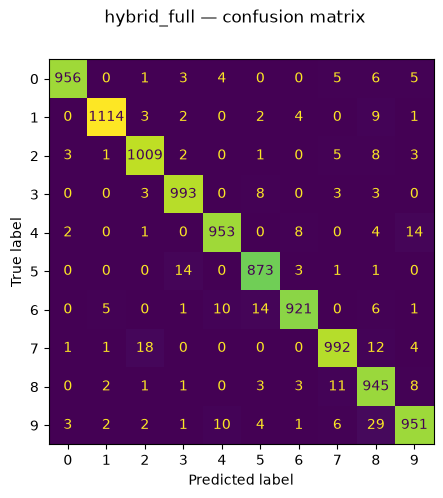

In [7]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in RUNS:
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)
    model = build_model(spec, config)
    if not (spec['results_dir'] / 'model.pt').exists():
        continue
    model.to(device)
    model.eval()
    with torch.no_grad():
        _, preds, labels = evaluate(model, test_loader, criterion, device)
    class_names = [str(c) for c in config['dataset']['classes']]
    fig = confusion_matrix_fig(labels, preds, class_names)
    fig.suptitle(f"{spec['label']} — confusion matrix")
    out_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(out_path)
    print(f'Saved {out_path}')
    display(fig)
